# Classifying Penguins with Keras

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn import preprocessing
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [5]:
from palmerpenguins import load_penguins
penguins = load_penguins()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [ ]:
#drop NAs
penguins = penguins.dropna()
penguins.shape 

(333, 8)

We lost 11 rows by dropping NAs.

In [38]:
#shuffle the data
penguins = penguins.sample(frac = 1, random_state = 321).reset_index(drop = True)

In [39]:
#define features
penguins_x = pd.concat([penguins[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']], pd.get_dummies(penguins['sex'])], axis = 1)
# penguins_x = penguins_x[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'female', 'male']]
penguins_x

,body_mass_g,bill_length_mm,bill_depth_mm,flipper_length_mm,female,male
0,4000.0,41.5,18.5,201.0,False,True
1,3900.0,47.5,16.8,199.0,True,False
2,4750.0,45.5,14.5,212.0,True,False
3,3550.0,39.0,17.5,186.0,True,False
4,5350.0,48.7,15.1,222.0,False,True
...,...,...,...,...,...,...
328,5050.0,45.0,15.4,220.0,False,True
329,3350.0,42.5,16.7,187.0,True,False
330,2900.0,43.2,16.6,187.0,True,False
331,3325.0,38.5,17.9,190.0,True,False


In [40]:
#have to scale numerical data for neural networks
x = penguins_x.values
min_max_scaler = preprocessing.MinMaxScaler()
scaled_penguins_x = pd.DataFrame(min_max_scaler.fit_transform(x), columns=penguins_x.columns)
scaled_penguins_x

,body_mass_g,bill_length_mm,bill_depth_mm,flipper_length_mm,female,male
0,0.361111,0.341818,0.642857,0.491525,0.0,1.0
1,0.333333,0.560000,0.440476,0.457627,1.0,0.0
2,0.569444,0.487273,0.166667,0.677966,1.0,0.0
3,0.236111,0.250909,0.523810,0.237288,1.0,0.0
4,0.736111,0.603636,0.238095,0.847458,0.0,1.0
...,...,...,...,...,...,...
328,0.652778,0.469091,0.273810,0.813559,0.0,1.0
329,0.180556,0.378182,0.428571,0.254237,1.0,0.0
330,0.055556,0.403636,0.416667,0.254237,1.0,0.0
331,0.173611,0.232727,0.571429,0.305085,1.0,0.0


In [41]:
#define target variable
penguins_y = penguins['species']
print(penguins_y)
penguins_y = penguins_y.astype('category').cat.codes.to_numpy()
penguins_y

0         Adelie
1      Chinstrap
2         Gentoo
3         Adelie
4         Gentoo
         ...    
328       Gentoo
329    Chinstrap
330    Chinstrap
331       Adelie
332       Adelie
Name: species, Length: 333, dtype: str


array([0, 1, 2, 0,
       2, 0, 1, 2,
       2, 2, 0, 0,
       1, 0, 0, 2,
       0, 2, 2, 0,
       0, 2, 0, 0,
       0, 0, 1, 2,
       2, 0, 2, 0,
       0, 0, 2, 0,
       1, 0, 2, 1,
       0, 1, 2, 2,
       0, 1, 0, 2,
       0, 2, 0, 2,
       1, 0, 0, 2,
       2, 0, 1, 1,
       0, 0, 0, 1,
       2, 2, 0, 0,
       2, 0, 1, 0,
       2, 0, 1, 0,
       0, 0, 0, 2,
       0, 1, 2, 2,
       0, 2, 0, 1,
       0, 0, 2, 1,
       1, 0, 0, 1,
       2, 0, 1, 0,
       2, 0, 2, 0,
       0, 1, 1, 1,
       1, 2, 0, 0,
       2, 2, 1, 2,
       2, 0, 0, 0,
       2, 0, 2, 1,
       0, 0, 0, 2,
       1, 2, 1, 2,
       1, 0, 1, 2,
       2, 2, 2, 1,
       1, 1, 1, 1,
       0, 2, 0, 2,
       0, 2, 2, 2,
       2, 1, 0, 2,
       2, 2, 0, 1,
       2, 0, 0, 1,
       1, 2, 0, 2,
       0, 0, 0, 2,
       2, 1, 0, 0,
       2, 0, 1, 0,
       0, 0, 1, 2,
       2, 0, 0, 0,
       1, 2, 2, 0,
       2, 0, 1, 2,
       1, 1, 2, 2,
       0, 2, 1, 2,
       2, 0, 1, 2,
       0, 0,

In [46]:
#construct the model
inputs = keras.Input(shape=(6,))
x = layers.Dense(7, activation = 'relu')(inputs)
x = layers.Dense(5, activation = 'relu')(x)
x = layers.Dense(3, activation = 'relu')(x)
outputs = layers.Dense(3, activation='softmax')(x) #sigmoid isn't a good choice here (only good for 2 classes), use softmax
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

In [23]:
model.summary()

Model: 
"penguin_model"
┏━━━━━━┳━━━━┳━━━┓
┃ Lay… ┃ O… ┃ … ┃
┃ (ty… ┃ S… ┃ # ┃
┡━━━━━━╇━━━━╇━━━┩
│ inp… │ (… │ 0 │
│ (In… │ 6) │   │
├──────┼────┼───┤
│ den… │ (… │ … │
│ (De… │ 7) │   │
├──────┼────┼───┤
│ den… │ (… │ … │
│ (De… │ 5) │   │
├──────┼────┼───┤
│ den… │ (… │ … │
│ (De… │ 3) │   │
├──────┼────┼───┤
│ den… │ (… │ … │
│ (De… │ 3) │   │
└──────┴────┴───┘
 Total params: 119 
(476.00 B)
 Trainable params: 
119 (476.00 B)
 Non-trainable 
params: 0 (0.00 B)


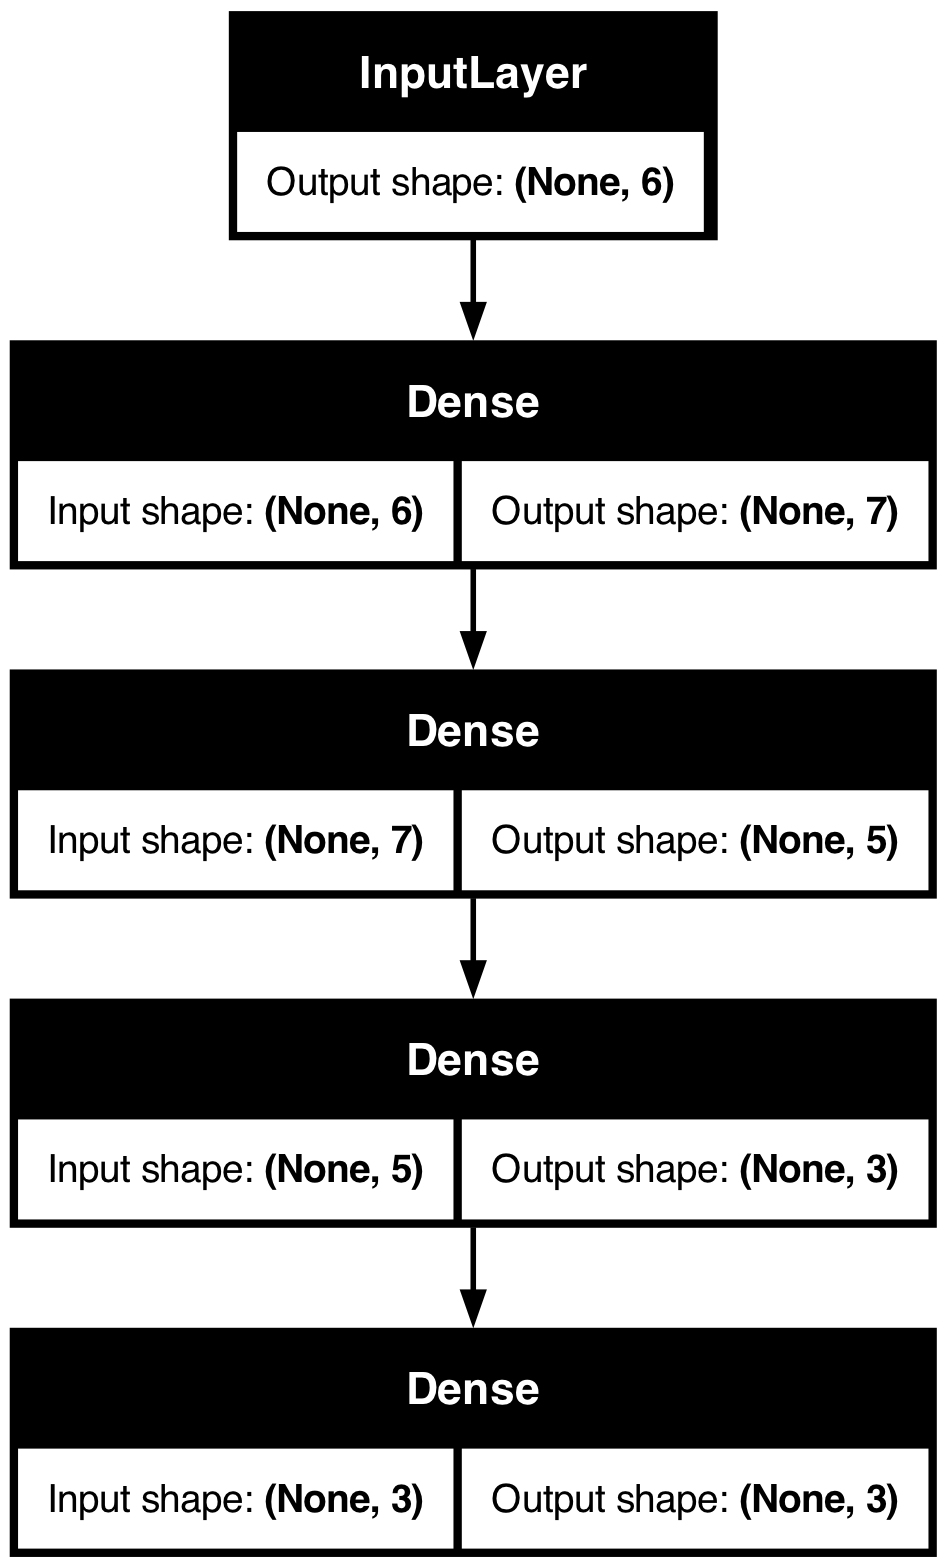

In [8]:
keras.utils.plot_model(model, show_shapes = True)

In [ ]:
#defines loss, optimizer, metric, and fits model
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), #tells model that softmax method gives raw numbers and we need to convert them to classes
    optimizer=keras.optimizers.RMSprop(),
    metrics=["accuracy"],
)

history = model.fit(scaled_penguins_x, penguins_y, batch_size = 64, epochs=100, validation_split=0.1) #need to make sure data is shuffled for validation

scores = model.evaluate(scaled_penguins_x, penguins_y, verbose=2)

Epoch 1/100


/Users/donyabehroozi/Documents/gsb545/GSB-545/tf_env/lib/python3.13/site-packages/keras/src/backend/tensorflow/nn.py:1216: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3579 - loss: 1.1335 - val_accuracy: 0.3529 - val_loss: 1.1308
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3579 - loss: 1.1228 - val_accuracy: 0.3529 - val_loss: 1.1210
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3579 - loss: 1.1156 - val_accuracy: 0.3529 - val_loss: 1.1127
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3579 - loss: 1.1094 - val_accuracy: 0.3529 - val_loss: 1.1042
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3579 - loss: 1.1036 - val_accuracy: 0.3529 - val_loss: 1.0974
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3579 - loss: 1.0982 - val_accuracy: 0.3824 - val_loss: 1.0897
Epoch 7/100


/Users/donyabehroozi/Documents/gsb545/GSB-545/tf_env/lib/python3.13/site-packages/keras/src/backend/tensorflow/nn.py:1216: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3679 - loss: 1.0930 - val_accuracy: 0.3824 - val_loss: 1.0829
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3712 - loss: 1.0879 - val_accuracy: 0.3824 - val_loss: 1.0764
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3846 - loss: 1.0829 - val_accuracy: 0.4118 - val_loss: 1.0700
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4080 - loss: 1.0783 - val_accuracy: 0.4412 - val_loss: 1.0634
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4582 - loss: 1.0736 - val_accuracy: 0.5294 - val_loss: 1.0577
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4916 - loss: 1.0691 - val_accuracy: 0.5588 - val_loss: 1.0517
Epoch 13/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5184 - loss: 1.0645 - val_accuracy: 0.5588 - val_loss: 1.0456
Epoch 14/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5251 - loss: 1.0599 - val_accuracy: 0.5588 - val_loss: 1.0393
Epoch 1

The model is not doing anything for us above because there are NAs in the penguins data! Note: we dropped NAs in a code cell above so code above looks good now.

In [ ]:
model_logit_false = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model_scaled")

model_logit_false.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False), #from_logits changed (tells model to not recalculate the classes since softmax does it for us)
    optimizer=keras.optimizers.RMSprop(),
    metrics=["accuracy"],
)

history_logit_true = model_logit_false.fit(scaled_penguins_x, penguins_y, batch_size = 64, epochs = 100, validation_split = 0.1)

scores = model_logit_false.evaluate(scaled_penguins_x, penguins_y, verbose = 2)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9431 - loss: 0.5237 - val_accuracy: 0.9118 - val_loss: 0.5128
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9498 - loss: 0.5157 - val_accuracy: 0.9118 - val_loss: 0.5087
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9532 - loss: 0.5115 - val_accuracy: 0.9118 - val_loss: 0.5056
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9532 - loss: 0.5069 - val_accuracy: 0.9118 - val_loss: 0.5016
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9532 - loss: 0.5030 - val_accuracy: 0.9118 - val_loss: 0.4983
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9532 - loss: 0.4988 - val_accuracy: 0.9118 - val_loss: 0.4954
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9532 - loss: 0.4950 - val_accuracy: 0.9118 - val_loss: 0.4924
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9498 - loss: 0.4913 - val_accuracy: 0.9118 - val_loss: 0.4894

In [ ]:
#raw probability predictions for each penguin species for each observation
model_logit_true.predict(scaled_penguins_x)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


array([[9.22418892e-01,
        7.67430291e-02,
        8.38103238e-04],
       [3.24486315e-01,
        4.50524032e-01,
        2.24989638e-01],
       [2.14559175e-02,
        5.74709335e-03,
        9.72796917e-01],
       [8.87466431e-01,
        1.12410657e-01,
        1.22966929e-04],
       [1.61806177e-02,
        3.28516401e-03,
        9.80534136e-01],
       [9.59057212e-01,
        4.09031399e-02,
        3.96858086e-05],
       [3.48637491e-01,
        6.27620637e-01,
        2.37419251e-02],
       [2.71879286e-02,
        9.21368506e-03,
        9.63598430e-01],
       [3.03410739e-02,
        1.14800669e-02,
        9.58178878e-01],
       [5.70585625e-03,
        4.07541229e-04,
        9.93886590e-01],
       [9.86258030e-01,
        1.37365479e-02,
        5.38590257e-06],
       [9.87506747e-01,
        1.24901729e-02,
        3.04932360e-06],
       [2.81047463e-01,
        6.48897052e-01,
        7.00554401e-02],
       [9.30654168e-01,
        6.92251101e-02,
   

In [50]:
penguins['species']

0         Adelie
1      Chinstrap
2         Gentoo
3         Adelie
4         Gentoo
         ...    
328       Gentoo
329    Chinstrap
330    Chinstrap
331       Adelie
332       Adelie
Name: species, Length: 333, dtype: str

In [45]:
penguins_y

array([0, 1, 2, 0,
       2, 0, 1, 2,
       2, 2, 0, 0,
       1, 0, 0, 2,
       0, 2, 2, 0,
       0, 2, 0, 0,
       0, 0, 1, 2,
       2, 0, 2, 0,
       0, 0, 2, 0,
       1, 0, 2, 1,
       0, 1, 2, 2,
       0, 1, 0, 2,
       0, 2, 0, 2,
       1, 0, 0, 2,
       2, 0, 1, 1,
       0, 0, 0, 1,
       2, 2, 0, 0,
       2, 0, 1, 0,
       2, 0, 1, 0,
       0, 0, 0, 2,
       0, 1, 2, 2,
       0, 2, 0, 1,
       0, 0, 2, 1,
       1, 0, 0, 1,
       2, 0, 1, 0,
       2, 0, 2, 0,
       0, 1, 1, 1,
       1, 2, 0, 0,
       2, 2, 1, 2,
       2, 0, 0, 0,
       2, 0, 2, 1,
       0, 0, 0, 2,
       1, 2, 1, 2,
       1, 0, 1, 2,
       2, 2, 2, 1,
       1, 1, 1, 1,
       0, 2, 0, 2,
       0, 2, 2, 2,
       2, 1, 0, 2,
       2, 2, 0, 1,
       2, 0, 0, 1,
       1, 2, 0, 2,
       0, 0, 0, 2,
       2, 1, 0, 0,
       2, 0, 1, 0,
       0, 0, 1, 2,
       2, 0, 0, 0,
       1, 2, 2, 0,
       2, 0, 1, 2,
       1, 1, 2, 2,
       0, 2, 1, 2,
       2, 0, 1, 2,
       0, 0,